In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

swedish_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/SWEDISH/results/output_tables/MSA_SWEDISH/pruned_attribution_MSA_SWEDISH_SBS_abs_mutations.csv',
                  index_col=0)

In [2]:
# only looking at nonzero samples for linear regression
swedish_msa = swedish_msa[swedish_msa.loc[:,'SBS288E'] > 0]

In [3]:
swed_metadata = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/data_from_other_papers/Swedish_data/supp_tables/Supplementary_Table_01.csv',index_col=1,
                           skiprows=[0,1])

# swedish_meta = swed_metadata.loc[:,['Sex','Age at diagnosis','Tumour Site']]
swed_metadata.columns = swed_metadata.columns.str.replace(' ','_')

swed_metadata = swed_metadata.loc[swedish_msa.index]

swed_metadata['age'] = swed_metadata.loc[:,'Age_at_diagnosis']
swed_metadata['sex'] = swed_metadata.loc[:,'Sex']
swed_metadata['subsite'] = swed_metadata.loc[:,'Tumour_Site']

swed_metadata['purity'] = swed_metadata.loc[:,'Tumour_Cell_Content_Pathology']/100

swed_metadata['SBS_D'] = swedish_msa.loc[:,'SBS288E'] 

In [4]:
from scipy import stats 
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm

import statsmodels.formula.api as smf

swed_metadata['age_diag'] = swed_metadata.loc[:,'Age_at_diagnosis']
swed_metadata['sex'] = swed_metadata.loc[:,'Sex']
swed_metadata['tumorsite_group'] = swed_metadata.loc[:,'Tumour_Site']
swed_metadata['tumor_subsite'] = swed_metadata.loc[:,'tumorsite_group']

swed_metadata['tumor_subsite'] = swed_metadata['tumor_subsite'].str.replace('Left Colon','Proximal colon').str.replace('Right Colon','Distal colon')


In [5]:
swed_metadata['Grade'] = swed_metadata.loc[:,'Tumour_Grade']

swed_metadata['stage'] = swed_metadata.loc[:,'Tumour_Stage'].str.split(' ').str[-1]
swed_metadata['simple_stage_numeric'] = swed_metadata['stage'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').astype(float)

swed_metadata['Stage'] = swed_metadata['stage'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').astype(float)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86619/2642727869.py:79: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(reset_labels)


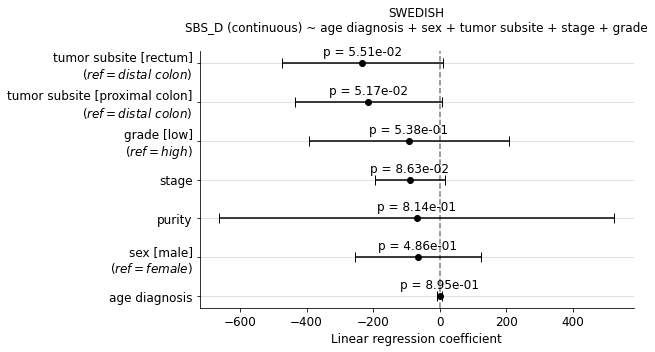

In [6]:
model = smf.glm(formula = 'SBS_D' + " ~ age_diag + sex + tumor_subsite + purity + Stage + Grade", 
            data =swed_metadata)
            #family = sm.families.Binomial())

result = model.fit()
result_table = result.summary2().tables[1]


from statsmodels.stats.multitest import multipletests



result_table=result_table.drop('Intercept')
result_table = result_table.reset_index()


result_table = result_table.sort_values('Coef.',ascending=False)


fig,ax = plt.subplots(figsize=(9,5))
plt.errorbar(result_table.loc[:,'Coef.'], result_table.loc[:,'index'],
             xerr=result_table.loc[:,'Std.Err.']*2, fmt="o",capsize=5,color='black')



result_table_ = result_table[result_table.loc[:,'P>|z|'] < .05]
# only report the dietary variables
# result_table_ = result_table[result_table.loc[:,'index'].isin(corrected[corrected<.05].index)]
plt.errorbar(result_table_.loc[:,'Coef.'], result_table_.loc[:,'index'],
             xerr=result_table_.loc[:,'Std.Err.']*2, fmt="o",color='red',capsize=5)

plt.xlabel('coef')
plt.axvline(0,color='black',alpha=.5,linestyle='--')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


result_table.index = result_table.loc[:,'index']
for i, txt in enumerate(result_table.loc[:,'P>|z|']):
    addition = ''
    y_numeric = ax.yaxis.convert_units(result_table.loc[:,'index'][i])
    offset = 0.2 
#     if 'freq' in result_table.index[i] and corrected.loc[result_table.index[i]] < 0.05:
#         addition = ' (q-value = ' + str(round(corrected.loc[result_table.index[i]],3)) + ')'
    ax.annotate('p = ' + '{:0.2e}'.format(txt) + addition,(result_table.loc[:,'Coef.'][i],
                      y_numeric + .2),fontsize=12,ha='center',
                
              )
# for i, txt in enumerate(result_table.loc[:,'P>|z|']):
#     ax.annotate('{:0.2e}'.format(txt),(result_table.loc[:,'0.975]'][i]+50,
#                       result_table.loc[:,'index'][i]),fontsize=14)

 
plt.xlabel('Linear regression coefficient')

reset_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
#     if variable in text:
#         label = label.set_color('blue')
    text = text.replace('[T.',' [').replace('_',' ').replace(' diag',' diagnosis').replace('Stage','stage').lower()
    if 'subsite' in text:
        text = text.replace(']',']\n$\mathit{(ref=distal\ colon)}$')
    
    if 'grade' in text:
        text = text.lower().replace(']',']\n$\mathit{(ref=high)}$').replace('low grade','low')
        
    if 'sex' in text:
        text = text.replace(']',']\n$\mathit{(ref=female)}$')
    reset_labels.append(text)    
    


ax.set_yticklabels(reset_labels) 
plt.grid(axis='y',alpha=.5)
# plt.grid(axis='y')

plt.title('SWEDISH\nSBS_D (continuous) ~ age diagnosis + sex + tumor subsite + stage + grade',
         pad=20)
plt.tight_layout()

# plt.savefig('plots_for_responses/Swedish_clinipatho_continuous.png',dpi=300)
